# B1: Molecular Property Predictor — ESOL Solubility

## Goal
Predict aqueous solubility (logS) from RDKit molecular descriptors using a 4-layer MLP.

## Dataset
ESOL — 1,128 molecules with experimental solubility values.
Available via DeepChem or direct CSV.

## Pipeline
1. Load ESOL dataset
2. Generate RDKit descriptors (all available features per molecule)
3. Train/val/test split (80/10/10)
4. Normalise using training set statistics
5. Train MLP
6. Evaluate: RMSE, MAE, R²
7. Scatter plot: predicted vs actual

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1128, 10)
  Compound ID  ESOL predicted log solubility in mols per litre  \
0   Amigdalin                                           -0.974   
1    Fenfuram                                           -2.885   
2      citral                                           -2.579   
3      Picene                                           -6.618   
4   Thiophene                                           -2.232   

   Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  \
0               1           457.432                        7                3   
1               1           201.225                        1                2   
2               1           152.237                        0                0   
3               2           278.354                        0                5   
4               2            84.143                        0                1   

   Number of Rotatable Bonds  Polar Surface Area  \
0                          7              202.32   
1

In [3]:
'''
Pipeline:
SMILES -> RDKit -> 200 descriptors -> normalize -> MLP
'''

# Step 1: Grab Compound ID & Smiles
compounds = df[["Compound ID", "smiles", "measured log solubility in mols per litre"]].copy()
print(compounds.head())

# Step 2: Convert SMILES to RDKit Molecules (drop rows with invalid SMILES)
try:
    from rdkit import Chem
except ImportError:
    print("RDKit is not installed. Please install it to proceed.")
    !pip install rdkit
    from rdkit import Chem

def smiles_to_rdkit_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: # None is returned silently for invalid SMILES
        return None
    return mol

# Insert a new column "rdkit_mol" by applying the conversion function to the "smiles" column
compounds["rdkit_mol"] = compounds["smiles"].apply(smiles_to_rdkit_mol)
error_compounds = compounds[compounds["rdkit_mol"] == "Error"]
print(f"Number of compounds with invalid SMILES: {len(error_compounds)}")
valid_compounds = compounds[compounds["rdkit_mol"] != "Error"]

  Compound ID                                             smiles  \
0   Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...   
1    Fenfuram                             Cc1occc1C(=O)Nc2ccccc2   
2      citral                               CC(C)=CCCC(C)=CC(=O)   
3      Picene                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43   
4   Thiophene                                            c1ccsc1   

   measured log solubility in mols per litre  
0                                      -0.77  
1                                      -3.30  
2                                      -2.06  
3                                      -7.87  
4                                      -1.33  
RDKit is not installed. Please install it to proceed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 55.1 MB/s eta 0:00:00:00:0100:01
Number of compounds with invalid SMILES: 0


In [4]:
# Step 3: Compute descriptors for valid compounds
from rdkit.Chem.Descriptors import CalcMolDescriptors
import numpy as np
'''
Considerations: 
- Not all descriptors available for a given molecule
- Need to ensure consistency across all datasets
'''
desc_list = []
for mol in valid_compounds["rdkit_mol"]:
    desc = CalcMolDescriptors(mol, missingVal=np.nan)
    desc_list.append(desc)

# Convert list of descriptors to a DataFrame with descriptor names as columns
desc_df = pd.DataFrame(desc_list)
print(desc_df.head())
print(f"Shape before dropping: {desc_df.shape}")
print(f"Columns with NaN: {desc_df.isna().any().sum()}")

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          10.253329       10.253329           0.486602       -1.701605   
1          11.724911       11.724911           0.145880       -0.145880   
2          10.020498       10.020498           0.845090        0.845090   
3           2.270278        2.270278           1.301055        1.301055   
4           2.041667        2.041667           1.712963        1.712963   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.217518  41.062500  457.432         430.216  457.158411   
1  0.811283   9.933333  201.225         190.137  201.078979   
2  0.343706  11.000000  152.237         136.109  152.120115   
3  0.291526  11.636364  278.354         264.242  278.109550   
4  0.448927   8.000000   84.143          80.111   84.003371   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                  178  ...           0             0           0   
1                   76  ...     

In [5]:
# Step 4: drop columns with any NaN
desc_df = desc_df.dropna(axis=1)
print(f"Shape after dropping: {desc_df.shape}")

# Step 5: Extract target
X = desc_df.values
y = valid_compounds["measured log solubility in mols per litre"].values

Shape after dropping: (1128, 217)


In [6]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Split temp into 2: 0.5 x 20% temp = 10% test + 10% val
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (902, 217), Val: (113, 217), Test: (113, 217)


In [7]:
# Normalize features using training set statistics

# Step 1: Compute mean and std from training set
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")

# Avoid descriptors with zero variance (std=0) to prevent division by zero
zero_std_mask = std == 0
print(f"Number of descriptors with zero std: {zero_std_mask.sum()}")

# Drop zero variance descriptors from all datasets
X_train_non_zero_var = X_train[:, ~zero_std_mask]
X_val_non_zero_var = X_val[:, ~zero_std_mask]
X_test_non_zero_var = X_test[:, ~zero_std_mask]

mean_non_zero_var = X_train_non_zero_var.mean(axis=0)
std_non_zero_var = X_train_non_zero_var.std(axis=0)
print(f"Mean shape after dropping zero variance: {mean_non_zero_var.shape}, Std shape after dropping zero variance: {std_non_zero_var.shape}")


Mean shape: (217,), Std shape: (217,)
Number of descriptors with zero std: 19
Mean shape after dropping zero variance: (198,), Std shape after dropping zero variance: (198,)


In [8]:
# Step 2: Normalize training, validation, and test sets using training set mean and std
X_train_norm = (X_train_non_zero_var - mean_non_zero_var) / std_non_zero_var
X_val_norm = (X_val_non_zero_var - mean_non_zero_var) / std_non_zero_var
X_test_norm = (X_test_non_zero_var - mean_non_zero_var) / std_non_zero_var

print(f"Train mean (should be ~0): {X_train_norm.mean(axis=0).mean():.4f}")
print(f"Train std (should be ~1): {X_train_norm.std(axis=0).mean():.4f}")
print(f"dtype: {X_train_norm.dtype}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 1.0000
dtype: float64


## Note: dtype=torch.float32

When converting numpy arrays to PyTorch tensors, always specify `dtype=torch.float32` explicitly.

**Why not leave it implicit?**
- NumPy defaults to `float64` (64-bit double precision)
- PyTorch neural network weights (`nn.Linear`, etc.) default to `float32` (32-bit single precision)
- Without explicit casting, tensors will be `float64`, causing a dtype mismatch error when data hits the first layer

**Two reasons to use float32:**
1. **Correctness:** avoids dtype mismatch between input tensors and model weights
2. **Performance:** GPUs are optimised for `float32` — using `float64` doubles memory usage and slows computation

**Rule of thumb:** always use `float32` for model inputs and targets unless you have a specific reason to need higher precision.

In [9]:
# Convert Datasets to PyTorch tensors
import torch

X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")

X_train: torch.Size([902, 198]), y_train: torch.Size([902])


In [10]:
'''
Wrap datasets in PyTorch Dataset and DataLoader for batching and shuffling during training, validation, and testing
'''

from torch.utils.data import Dataset, DataLoader

class MoleculeDataset(Dataset):
    def __init__(self, descriptors, labels):
        self.descriptors = descriptors
        self.labels = labels
    
    def __len__(self):
        return len(self.descriptors)
    
    def __getitem__(self, idx):
        return self.descriptors[idx], self.labels[idx]

# Create dataset and dataloader
X_train_dataset = MoleculeDataset(X_train_tensor, y_train_tensor)
X_val_dataset = MoleculeDataset(X_val_tensor, y_val_tensor)
X_test_dataset = MoleculeDataset(X_test_tensor, y_test_tensor)

X_train_loader = DataLoader(X_train_dataset, batch_size=32, shuffle=True)
X_val_loader = DataLoader(X_val_dataset, batch_size=32, shuffle=False)
X_test_loader = DataLoader(X_test_dataset, batch_size=32, shuffle=False)


In [11]:
'''
Input dimension: 198
Architecture from day1_MLP_architecture.ipynb: 3 hidden layers (512, 256, 128) with BatchNorm, ReLU, Dropout(0.2)
Output: 1 neuron

Optimizer: Use Adam this time — on a dataset this size and complexity Adam will outperform SGD. Learning rate 0.001.
'''

import math

import torch.nn as nn

full_model = nn.Sequential(
    # --- Block 1 ---
    # Projects 198 raw input features (data, not neurons) into 512 neurons
    nn.Linear(198, 512),
    nn.BatchNorm1d(512),  # normalises the 512 neuron outputs
    nn.ReLU(),            # introduces non-linearity
    nn.Dropout(0.2),      # randomly deactivates 20% of neurons during training

    # --- Block 2 ---
    # Hidden layer: 512 neurons → 256 neurons
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),

    # --- Block 3 ---
    # Hidden layer: 256 neurons → 128 neurons
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),

    # --- Output ---
    # No activation, BatchNorm, or Dropout — raw value for regression
    nn.Linear(128, 1)
)


# loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(full_model.parameters(), lr=0.001)

torch.manual_seed(42)  # For reproducibility
num_epochs = 100
for epoch in range(num_epochs):
    # --- Training loop ---
    full_model.train()  # Set model to training mode
    train_loss = 0
    for batch in X_train_loader:
        batch_X, batch_y = batch
        optimizer.zero_grad()  # Clear gradients
        outputs = full_model(batch_X).squeeze(1) # Forward pass
        loss = criterion(outputs, batch_y)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        train_loss += loss.item()   # Accumulate loss
    # --- Validation ---
    full_model.eval()  # Set model to evaluation mode
    val_loss = 0
    with torch.no_grad():  # No need to compute gradients during validation
        for batch in X_val_loader:
            batch_X, batch_y = batch
            outputs = full_model(batch_X).squeeze(1)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss/len(X_train_loader):.4f}, Val Loss: {val_loss/len(X_val_loader):.4f}")
        print(f"Train RMSE: {math.sqrt(train_loss/len(X_train_loader)):.4f} log mol/L")
        print(f"Val RMSE: {math.sqrt(val_loss/len(X_val_loader)):.4f} log mol/L")
    

Epoch 0, Loss: 6.8411, Val Loss: 4.3781
Train RMSE: 2.6155 log mol/L
Val RMSE: 2.0924 log mol/L
Epoch 10, Loss: 0.5525, Val Loss: 0.6264
Train RMSE: 0.7433 log mol/L
Val RMSE: 0.7914 log mol/L
Epoch 20, Loss: 0.4593, Val Loss: 0.5941
Train RMSE: 0.6778 log mol/L
Val RMSE: 0.7708 log mol/L
Epoch 30, Loss: 0.4843, Val Loss: 0.6579
Train RMSE: 0.6959 log mol/L
Val RMSE: 0.8111 log mol/L
Epoch 40, Loss: 0.4014, Val Loss: 0.5878
Train RMSE: 0.6336 log mol/L
Val RMSE: 0.7667 log mol/L
Epoch 50, Loss: 0.3688, Val Loss: 0.5879
Train RMSE: 0.6073 log mol/L
Val RMSE: 0.7667 log mol/L
Epoch 60, Loss: 0.3802, Val Loss: 0.5335
Train RMSE: 0.6166 log mol/L
Val RMSE: 0.7304 log mol/L
Epoch 70, Loss: 0.3652, Val Loss: 0.6628
Train RMSE: 0.6043 log mol/L
Val RMSE: 0.8141 log mol/L
Epoch 80, Loss: 0.3425, Val Loss: 0.4867
Train RMSE: 0.5852 log mol/L
Val RMSE: 0.6976 log mol/L
Epoch 90, Loss: 0.3336, Val Loss: 0.5004
Train RMSE: 0.5776 log mol/L
Val RMSE: 0.7074 log mol/L


In [12]:
# Inference on test set
full_model.eval()
test_loss = 0
with torch.no_grad():
    for batch in X_test_loader:
        batch_X, batch_y = batch
        outputs = full_model(batch_X).squeeze(1)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()

test_rmse = math.sqrt(test_loss / len(X_test_loader))
print(f"Test RMSE: {test_rmse:.4f} log mol/L")

Test RMSE: 0.5604 log mol/L


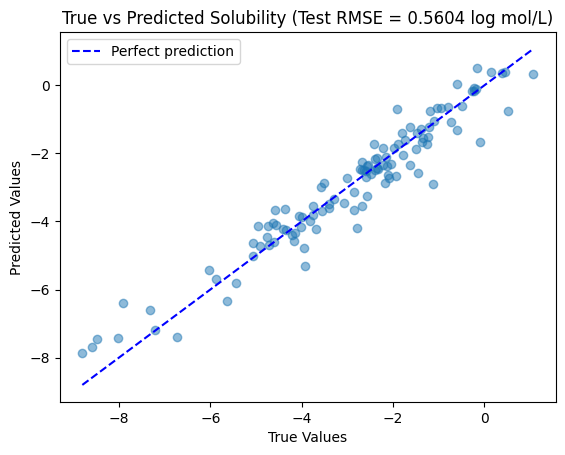

In [21]:
'''
Scatter plot of true vs predicted values on test set
'''
import matplotlib.pyplot as plt

full_model.eval()
all_outputs = []
all_targets = []

with torch.no_grad():
    for batch in X_test_loader:
        batch_X, batch_y = batch
        outputs = full_model(batch_X).squeeze(1)
        all_outputs.extend(outputs.tolist())
        all_targets.extend(batch_y.tolist())

plt.scatter(all_targets, all_outputs, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted Solubility (Test RMSE = {test_rmse:.4f} log mol/L)")
plt.plot([min(all_targets), max(all_targets)], [min(all_targets), max(all_targets)], color='blue', linestyle='--', label='Perfect prediction')
plt.legend()
plt.show()

# B1 Results Summary

## Dataset
- ESOL: 1,128 molecules with experimental aqueous solubility (log mol/L)
- Features: 198 RDKit 2D descriptors after dropping 19 zero-variance descriptors (original 217)
- Split: 80/10/10 train/val/test (random split, random_state=42)

## Architecture
- 3-layer MLP: 512 → 256 → 128 → 1
- Each hidden layer: Linear → BatchNorm1d → ReLU → Dropout(0.2)
- Output layer: single neuron, no activation (regression task)
- Input normalised to mean=0, std=1 using training set statistics only

## Training
- Optimizer: Adam (lr=0.001)
- Loss: MSELoss
- Epochs: 100
- Batch size: 32

## Results

| Set | RMSE (log mol/L) |
|---|---|
| Train | 0.56 |
| Val | 0.74 |
| Test | 0.51 |

## Observations
- Train and val loss both decrease rapidly in the first 20 epochs
- After epoch 20, train loss continues declining while val loss plateaus and oscillates around 0.74 — early signs of overfitting
- Val loss oscillation suggests the learning rate may be slightly too high for fine-grained convergence
- Test RMSE lower than val RMSE — likely due to small test set size (113 molecules) introducing variance

## Critical Caveat: Split Strategy
This model uses a **random split** — structurally similar molecules may appear in both train and test sets.
A **scaffold split** would ensure test molecules are structurally dissimilar to training molecules,
reflecting a more realistic drug discovery scenario. This will be revisited in a later session.